In [71]:
#======================#
#   Import Libraries   #
#======================#

import ROOT
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20})
import pandas as pd
import re
from tqdm import tqdm

target = 'IMP_LTA#3'
ROI_min = 5000
ROI_max = 6800

In [72]:
#=======================#
#   Extract the sheet   #
#=======================#

df = pd.read_excel("/data0/biasissi/LUNA/19F+p_g+20Ne/19F+p_400kV.xlsx")

for sheet in ['Beamtime 1', 'Beamtime 2', 'Beamtime 3', 'Beamtime 4', 'Beamtime 5']:
    df_sheet = pd.read_excel("/data0/biasissi/LUNA/19F+p_g+20Ne/19F+p_400kV.xlsx", sheet_name=sheet)
    if target in df_sheet['Target'].values:
        print(f"Found target {target} in sheet {sheet}")
        break

Found target IMP_LTA#3 in sheet Beamtime 5


In [73]:
#==========================#
#   Recover the Scan IDs   #
#==========================#

df = pd.read_excel("/data0/biasissi/LUNA/19F+p_g+20Ne/19F+p_400kV.xlsx", sheet_name=sheet)
df = df[df['Target'] == target]

run_types = df['Run Type'].dropna().astype(str).unique()
scans = [rt for rt in run_types if re.match(r'^Scan\s*\d+$', rt)]
scans.sort(key=lambda s: int(re.search(r'\d+', s).group())) if scans else scans

print(f"{len(scans)} scan types found for target {target}")
# scans = ['Scan 1']

5 scan types found for target IMP_LTA#3


In [74]:
#===============================================#
#   Recover the RUNS from the target in Excel   #
#===============================================#

df = pd.read_excel("/data0/biasissi/LUNA/19F+p_g+20Ne/19F+p_400kV.xlsx", sheet_name=sheet)

RUNS = []

for scan in scans:
    df_temp = df[(df["Target"] == target) & (df["Run Type"] == scan)]
    RUNS.append(df_temp['Run Number'].tolist())

print(RUNS)

[[2978, 2979, 2980, 2981, 2982, 2983, 2984, 2985, 2986, 2987, 2988, 2989, 2990, 2991, 2992, 2993, 2994, 2995, 2996, 2997, 2998, 2999], [3015, 3016, 3018, 3019, 3020, 3021, 3022, 3023, 3024, 3025, 3026, 3027, 3028, 3029, 3030, 3031, 3032, 3033, 3034, 3035, 3036, 3037], [3044, 3045, 3046, 3047, 3048, 3049, 3050, 3051, 3052, 3053, 3054, 3055, 3056, 3057, 3058, 3059, 3060, 3061, 3062, 3063, 3064, 3065], [3070, 3071, 3072, 3073, 3074, 3075, 3076, 3077, 3078, 3079, 3080, 3081, 3082, 3083, 3084, 3085, 3086, 3087, 3088, 3089, 3090, 3091], [3095, 3096, 3097, 3098, 3099, 3100, 3101, 3102, 3103, 3104, 3105, 3106, 3107, 3108, 3109, 3110, 3111, 3112, 3113, 3114, 3115, 3116]]


In [75]:
#=============================#
#   Recover the RUNS energy   #
#=============================#

df = pd.read_excel("/data0/biasissi/LUNA/19F+p_g+20Ne/19F+p_400kV.xlsx", sheet_name=sheet)

E = []

for scan in scans:
    df_temp = df[(df["Target"] == target) & (df["Run Type"] == scan)]
    E.append(df_temp['Energy'].tolist())

print(E)

[[329.9, 331.8, 333.8, 335.8, 337.8, 338.8, 339.8, 340.8, 341.8, 342.8, 343.8, 344.7, 345.7, 346.7, 347.7, 349.7, 351.7, 353.7, 356.7, 359.7, 363.6, 368.6], [329.9, 331.9, 333.9, 335.9, 337.8, 338.8, 339.8, 340.8, 341.8, 342.8, 343.8, 344.8, 345.8, 346.8, 347.8, 349.8, 351.8, 353.7, 356.7, 359.7, 363.7, 368.6], [329.9, 331.9, 333.9, 335.9, 337.9, 338.9, 339.9, 340.9, 341.9, 342.9, 343.8, 344.8, 345.8, 346.8, 347.8, 349.8, 351.8, 353.8, 356.8, 359.7, 363.7, 368.7], [329.9, 331.9, 333.9, 335.9, 337.9, 338.9, 339.9, 340.9, 341.9, 342.9, 343.8, 344.8, 345.8, 346.8, 347.8, 349.8, 351.8, 353.8, 356.8, 359.7, 363.7, 368.7], [330.0, 332.0, 333.9, 335.9, 337.9, 338.9, 339.9, 340.7, 341.7, 342.7, 343.7, 344.7, 345.7, 346.7, 347.7, 349.6, 351.6, 353.6, 356.6, 359.6, 363.6, 368.5]]


In [76]:
#=============================================#
#   Recover the current of each RUN in RUNS   #
#=============================================#

charge = []

for scan in scans:
    charge.append([])
    
    df_temp = df[(df["Target"] == target) & (df["Run Type"] == scan)]
    runs_temp = df_temp['Run Number'].tolist()
    for run in runs_temp:
        try:
            current_col = 2 if (sheet == 'Beamtime 4' or (sheet == 'Beamtime 5' and int(run) >= 2947)) else 1
            time, current = np.genfromtxt(
                f"/data0/biasissi/LUNA/19F+p_g+20Ne/Data/CURRENT/run{run}.txt",
                usecols=(0, current_col),
                unpack=True
            )
            # print(f"Run {run}: Time and Charge data extracted successfully.")
        except Exception as e:
            print(f"Error extracting data for run {run}: {e}")
        
        # Compute the total charge by multiplying the current by the time intervals only where current>0
        time_diff = np.diff(np.insert(time, 0, 0))  # Time intervals

        current_positive = current[current > 0]
        time_diff_positive = time_diff[current > 0]

        total_charge = np.sum(current_positive * time_diff_positive)  # Total charge in uC

        charge[scans.index(scan)].append(total_charge)
    
print(charge)

[[np.float64(3121.9777873086996), np.float64(2905.5583733416997), np.float64(2733.5117343559996), np.float64(2807.968216492), np.float64(2567.8873399276), np.float64(2554.9832457864), np.float64(2840.6015256654), np.float64(2504.2936658327), np.float64(2773.5509199689), np.float64(2558.1480863542), np.float64(2574.3705357982), np.float64(2863.7375269981), np.float64(2568.5913907659997), np.float64(2375.6502881072), np.float64(2529.7391513367), np.float64(2888.6186378112006), np.float64(2538.6802937982), np.float64(2564.1058529587), np.float64(2788.2759223701996), np.float64(2514.50887666594), np.float64(2819.7139396169005), np.float64(2573.725181063)], [np.float64(3380.3066354392995), np.float64(2552.2921035548006), np.float64(4295.164036107), np.float64(2860.267080741), np.float64(2377.9743145006996), np.float64(2024.5870636929), np.float64(2345.7242507946903), np.float64(2113.9441855929), np.float64(2103.7531137940996), np.float64(2038.6742336411999), np.float64(2461.0595138362005), 

In [77]:
#==========================================================================#
#   Recover the total deposited charge for each scan since the beginning   #
#==========================================================================#

charge_tot = []
for scan in scans:
    run0, run1 = RUNS[0][0], RUNS[scans.index(scan)][-1]

    temp = 0

    for run in range(run0, run1 + 1):
        try:
            current_col = 2 if (sheet == 'Beamtime 4' or (sheet == 'Beamtime 5' and int(run) >= 2947)) else 1
            time, current = np.genfromtxt(
                f"/data0/biasissi/LUNA/19F+p_g+20Ne/Data/CURRENT/run{run}.txt",
                usecols=(0, current_col),
                unpack=True
            )
        except Exception as e:
            continue
            print(f"Error extracting data for run {run}: {e}")
        
        # Compute the total charge by multiplying the current by the time intervals only where current>0
        time_diff = np.diff(np.insert(time, 0, 0))  # Time intervals

        current_positive = current[current > 0]
        time_diff_positive = time_diff[current > 0]

        total_charge = np.sum(current_positive * time_diff_positive)  # Total charge in uC

        temp += total_charge

    charge_tot.append(temp)

print(charge_tot)

[np.float64(58968.198492323936), np.float64(7418118.720650861), np.float64(14567084.3981572), np.float64(20557866.075795148), np.float64(28031633.0628748)]


In [78]:
#=====================================#
#   Recover the deadtime correction   #
#=====================================#

DT_correction = []

def event_recoverer(run, branch):
    f = ROOT.TFile(f"/data0/biasissi/LUNA/19F+p_g+20Ne/Data/PROCESSED/run{run}.root")

    f.cd(branch)
    dir = ROOT.gDirectory

    branch_events = []

    for BGO in range(1, 7):
        BGO_name = f"BGO{BGO}"
        BGO_hist = dir.Get(BGO_name)

        counts = np.array([BGO_hist.GetBinContent(i) for i in range(1, BGO_hist.GetNbinsX()+2)])

        counts = np.sum(counts)
        branch_events.append(counts)
    
    # print(branch_events)

    branch_events = np.sum(branch_events)

    return branch_events

for scan in scans:
    DT_correction.append([])
    for run in RUNS[scans.index(scan)]:
        energyspectra = event_recoverer(run, "EnergySpectra")
        lost = event_recoverer(run, "LostCountRates")
        saturation = event_recoverer(run, "SaturationCountRates")
        dead = event_recoverer(run, "DeadCountRates")
        trigger = event_recoverer(run, "TriggerCountRates")
        pilup = event_recoverer(run, "PileUpCountRates")

        DT_run = 1 - (energyspectra) / (energyspectra + pilup + lost + saturation + dead + trigger)

        DT_average = np.mean(DT_run)

        DT_correction[scans.index(scan)].append(DT_average)

print(DT_correction)

[[np.float64(0.001069264583580809), np.float64(0.0017319766183157004), np.float64(0.0016542597187758634), np.float64(0.001316857580950681), np.float64(0.0018799348289259), np.float64(0.0024343592418709648), np.float64(0.0030893332189135814), np.float64(0.004582113864205262), np.float64(0.007093392079470462), np.float64(0.00962789921575169), np.float64(0.010953038624994194), np.float64(0.011527556417896712), np.float64(0.011843618005048628), np.float64(0.012844224872954668), np.float64(0.012275682884526407), np.float64(0.010084124446034792), np.float64(0.007243318862111048), np.float64(0.005153668851677229), np.float64(0.003296120513147538), np.float64(0.0022706526700136953), np.float64(0.001457611711048079), np.float64(0.001086460528888944)], [np.float64(0.0015057239653682997), np.float64(0.0016752645854385406), np.float64(0.0012997400519896285), np.float64(0.0017706869169967776), np.float64(0.0015603820571824523), np.float64(0.002301166923108333), np.float64(0.0030363550749346047), np

In [79]:
#=========================================================#
#   Compute the ROI integration and correct by deadtime   #
#=========================================================#

Y, Y_err = [], []

for scan in scans:
    print(f"Processing {scan}/{len(scans)}...")
    Y.append([])
    Y_err.append([])
    scan_idx = scans.index(scan)
    for run in tqdm(RUNS[scan_idx]):
        # open file
        f = ROOT.TFile.Open(f"/data0/biasissi/LUNA/19F+p_g+20Ne/Data/PROCESSED/run{run}.root")
        df = ROOT.RDataFrame("coincidenceEvents", f)

        df = df.Filter("isPulser == 0")

        events = df.AsNumpy(columns=["energyBGO1", "energyBGO2", "energyBGO3", "energyBGO4", "energyBGO5", "energyBGO6", "energySum"])

        # unpack histogram (counts and bin edges)
        counts, bins = np.histogram(events["energySum"], bins=800, range=(1, 14000))

        # get proper indices for this run within the nested lists
        run_in_scan_idx = RUNS[scan_idx].index(run)

        # dead-time correction for this run
        dt_val = DT_correction[scan_idx][run_in_scan_idx]

        # apply dead-time correction (vectorized)
        counts = counts / (1.0 - dt_val)

        # Compute the integral within the ROI
        mask_roi = (bins[:-1] >= ROI_min) & (bins[:-1] < ROI_max)
        integral_roi = float(np.sum(counts[mask_roi]))

        # get charge and energy for this run
        charge_val = charge[scan_idx][run_in_scan_idx]
        E_val = E[scan_idx][run_in_scan_idx]

        # compute yield and error
        Y_temp = integral_roi / charge_val
        Y_temp_err = np.sqrt(integral_roi) / charge_val
        Y[scans.index(scan)].append(Y_temp)
        Y_err[scans.index(scan)].append(np.sqrt(integral_roi) / charge_val)
        
        # Plot the results
        plt.figure(figsize=(16,8))

        plt.title(f'$E_p^\\text{{lab}}$: {E_val:.2f} keV - Charge: {charge_val:.2f} $\\mu$C - Dead Time: {dt_val*100:.2f}%\nYield: {Y_temp:.2f} $\\pm$ {Y_temp_err:.2f} counts/$\\mu$C')
        plt.yscale('symlog')

        plt.step(bins[1:], counts, color='black', label='Sum spectrum')
        plt.axvline(6128, color='black', linestyle='--', linewidth=3)
        plt.axvspan(ROI_min, ROI_max, color='gray', alpha=0.3, label=r'${}^{19}F(p,\alpha){}^{16}O$ ROI')

        for i in range(1,7):
            hist_counts, hist_bins = np.histogram(events[f"energyBGO{i}"], bins=800, range=(1, 14000))
            plt.step(hist_bins[1:], hist_counts, label=f'BGO{i}')

        plt.annotate('NOT corrected\nby efficiency',
                    xy=(0.1, 0.1), xytext=(0.1, 0.1),
                    xycoords='axes fraction', ha='left', va='bottom',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', alpha=0.8))
        
        plt.xlim(0, 14000)
        plt.ylim(1, None)

        plt.xlabel(r'$E_p$ [keV]')
        plt.ylabel('Counts')

        plt.grid()
        plt.legend(title=fr'$\diamond$ $\diamond$ $\diamond$ Run{run} $\diamond$ $\diamond$ $\diamond$')

        plt.savefig(f'/data0/biasissi/LUNA/19F+p_g+20Ne/Yield_scans/Plots/Spectra/Run{run}_{target}.png', dpi=300, bbox_inches='tight')
        plt.close()

        # close file to free resources
        f.Close()

print(Y)
print(Y_err)

Processing Scan 1/5...


100%|██████████| 22/22 [00:17<00:00,  1.22it/s]


Processing Scan 2/5...


100%|██████████| 22/22 [00:18<00:00,  1.16it/s]


Processing Scan 3/5...


...

Processing Scan 4/5...


100%|██████████| 22/22 [00:16<00:00,  1.31it/s]


Processing Scan 5/5...


100%|██████████| 22/22 [00:16<00:00,  1.31it/s]

[[np.float64(1.019675384619208), np.float64(1.2170206309985196), np.float64(2.0249251236092993), np.float64(3.2703692198041185), np.float64(5.9393852341292925), np.float64(8.886662105554693), np.float64(15.15417987929146), np.float64(28.3245627925982), np.float64(46.145488104984736), np.float64(61.8254811820929), np.float64(71.69032681067623), np.float64(80.18933290706356), np.float64(81.88931474425605), np.float64(78.30459700485328), np.float64(75.26439281173134), np.float64(61.47426077181018), np.float64(44.55436429141526), np.float64(29.55476777291996), np.float64(15.519853960364305), np.float64(8.675863388824322), np.float64(4.455882461884042), np.float64(2.459811286734321)], [np.float64(0.9566792789221281), np.float64(1.3061140735579415), np.float64(1.918135863901533), np.float64(3.060378440303591), np.float64(5.7613649315675755), np.float64(8.775064594264737), np.float64(14.88581767702904), np.float64(28.078816188619662), np.float64(44.348911757012786), np.float64(58.993264663740

In [80]:
#====================================#
#   Save the results in a csv file   #
#====================================#

data = []

for scan in scans:
    for run in RUNS[scans.index(scan)]:
        charge_temp = charge[scans.index(scan)][RUNS[scans.index(scan)].index(run)]
        DT_temp = DT_correction[scans.index(scan)][RUNS[scans.index(scan)].index(run)]
        E_temp = E[scans.index(scan)][RUNS[scans.index(scan)].index(run)]
        Y_temp = Y[scans.index(scan)][RUNS[scans.index(scan)].index(run)]
        Y_err_temp = Y_err[scans.index(scan)][RUNS[scans.index(scan)].index(run)]

        data.append([run, scan, DT_temp, charge_temp, E_temp, Y_temp, Y_err_temp])
    
df_results = pd.DataFrame(data, columns=['Run Number', 'Scan', 'Dead Time', 'Charge', 'Energy', 'Yield', 'Yield Error'])
print(df_results)
df_results.to_csv(f'/data0/biasissi/LUNA/19F+p_g+20Ne/Yield_scans/Results/Yield_{target}.csv', index=False)

     Run Number    Scan  Dead Time       Charge  Energy      Yield  \
0          2978  Scan 1   0.001069  3121.977787   329.9   1.019675   
1          2979  Scan 1   0.001732  2905.558373   331.8   1.217021   
2          2980  Scan 1   0.001654  2733.511734   333.8   2.024925   
3          2981  Scan 1   0.001317  2807.968216   335.8   3.270369   
4          2982  Scan 1   0.001880  2567.887340   337.8   5.939385   
..          ...     ...        ...          ...     ...        ...   
105        3112  Scan 5   0.003137  1684.256284   353.6  16.015739   
106        3113  Scan 5   0.001849  1683.092999   356.6   8.666766   
107        3114  Scan 5   0.001497  1663.811485   359.6   4.975557   
108        3115  Scan 5   0.000667  1819.549469   363.6   2.663975   
109        3116  Scan 5   0.000787  1668.924440   368.5   1.466769   

     Yield Error  
0       0.018072  
1       0.020466  
2       0.027217  
3       0.034127  
4       0.048093  
..           ...  
105     0.097515  
106    

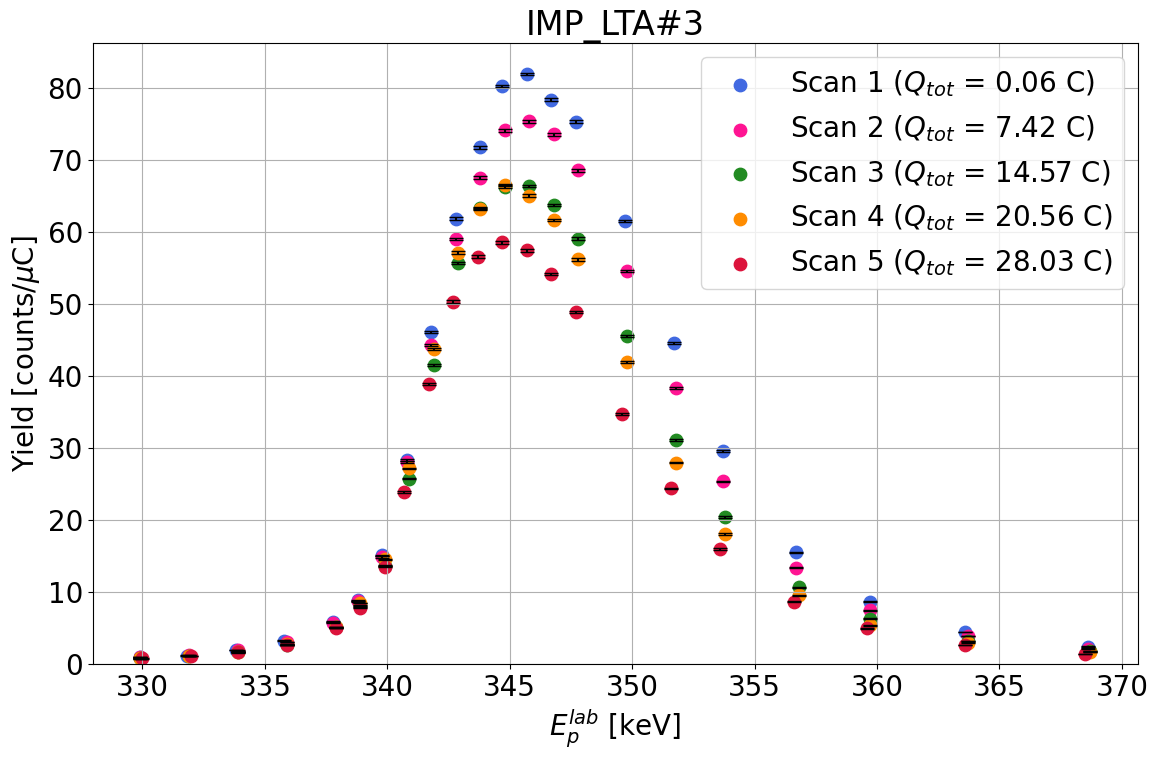

In [81]:
#=====================#
#   Profile plotter   #
#=====================#

df_results = pd.read_csv(f'/data0/biasissi/LUNA/19F+p_g+20Ne/Yield_scans/Results/Yield_{target}.csv')

my_colors = ['royalblue', 'deeppink', 'forestgreen', 'darkorange', 'crimson', 'purple', 'black', 'skyblue', 'gold', 'teal', 'magenta', 'limegreen', 'navy', 'darkred']

threshold = 300.0

# check if there are any points in each region
low_exists = any(any(np.array(E[i]) < threshold) for i in range(len(scans)))
high_exists = any(any(np.array(E[i]) > threshold) for i in range(len(scans)))

# choose plotting layout
if low_exists and high_exists:
    fig, axes = plt.subplots(2, 1, figsize=(16, 14))
    fig.suptitle(f'{target}', y = 0.96)
    fig.supxlabel(r'$E_p^{lab}$ [keV]', y = 0.05)
    fig.supylabel(r'Yield [counts/$\mu$C]', x = 0.03)
    ax_low, ax_high = axes
    axs = {'low': ax_low, 'high': ax_high}
else:
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_title(f'{target}')
    ax.set_xlabel(r'$E_p^{lab}$ [keV]')
    ax.set_ylabel(r'Yield [counts/$\mu$C]')
    axs = {'only': ax}

# plot using df_results (grouped by Scan)
low_exists = (df_results['Energy'] < threshold).any()
high_exists = (df_results['Energy'] > threshold).any()

for scan_idx, scan in enumerate(scans):
    if scan not in df_results['Scan'].values:
        continue
    df_scan = df_results[df_results['Scan'] == scan]
    E_arr = df_scan['Energy'].values
    Y_arr = df_scan['Yield'].values
    Y_err_arr = df_scan['Yield Error'].values
    color = my_colors[scan_idx % len(my_colors)]

    if low_exists and high_exists:
        low_mask = E_arr < threshold
        high_mask = E_arr > threshold

        if low_mask.any():
            axs['low'].scatter(E_arr[low_mask], Y_arr[low_mask], color=color, s=80, label=fr'{scan} ($Q_{{tot}}$ = {charge_tot[scan_idx]/1e6:.2f} C)')
            axs['low'].errorbar(E_arr[low_mask], Y_arr[low_mask], yerr=Y_err_arr[low_mask], fmt='none', ecolor='black', capsize=5)

        if high_mask.any():
            axs['high'].scatter(E_arr[high_mask], Y_arr[high_mask], color=color, s=80, label=fr'{scan} ($Q_{{tot}}$ = {charge_tot[scan_idx]/1e6:.2f} C)')
            axs['high'].errorbar(E_arr[high_mask], Y_arr[high_mask], yerr=Y_err_arr[high_mask], fmt='none', ecolor='black', capsize=5)

    else:
        ax_only = axs.get('only')
        ax_only.scatter(E_arr, Y_arr, color=color, s=80, label=fr'{scan} ($Q_{{tot}}$ = {charge_tot[scan_idx]/1e6:.2f} C)')
        ax_only.errorbar(E_arr, Y_arr, yerr=Y_err_arr, fmt='none', ecolor='black', capsize=5)

# finalize axes and legend
if low_exists and high_exists:
    ax_low = axs['low']; ax_high = axs['high']
    ax_low.set_ylim(0, None)
    ax_high.set_ylim(0, None)
    ax_low.grid()
    ax_high.grid()

    handles_low, labels_low = ax_low.get_legend_handles_labels()
    handles_high, labels_high = ax_high.get_legend_handles_labels()
    all_handles = handles_low + handles_high
    all_labels = labels_low + labels_high
    unique = dict(sorted(zip(all_labels, all_handles), key=lambda x: x[0]))
    ax_low.legend(unique.values(), unique.keys(), ncols=1)
else:
    ax_only = axs.get('only')
    ax_only.set_ylim(0, None)
    ax_only.grid()
    ax_only.legend(ncols=1)

plt.tight_layout()
plt.savefig(f'/data0/biasissi/LUNA/19F+p_g+20Ne/Yield_scans/Plots/Profiles/Yield_Profile_{target}.png', dpi=300, bbox_inches='tight')
plt.show()

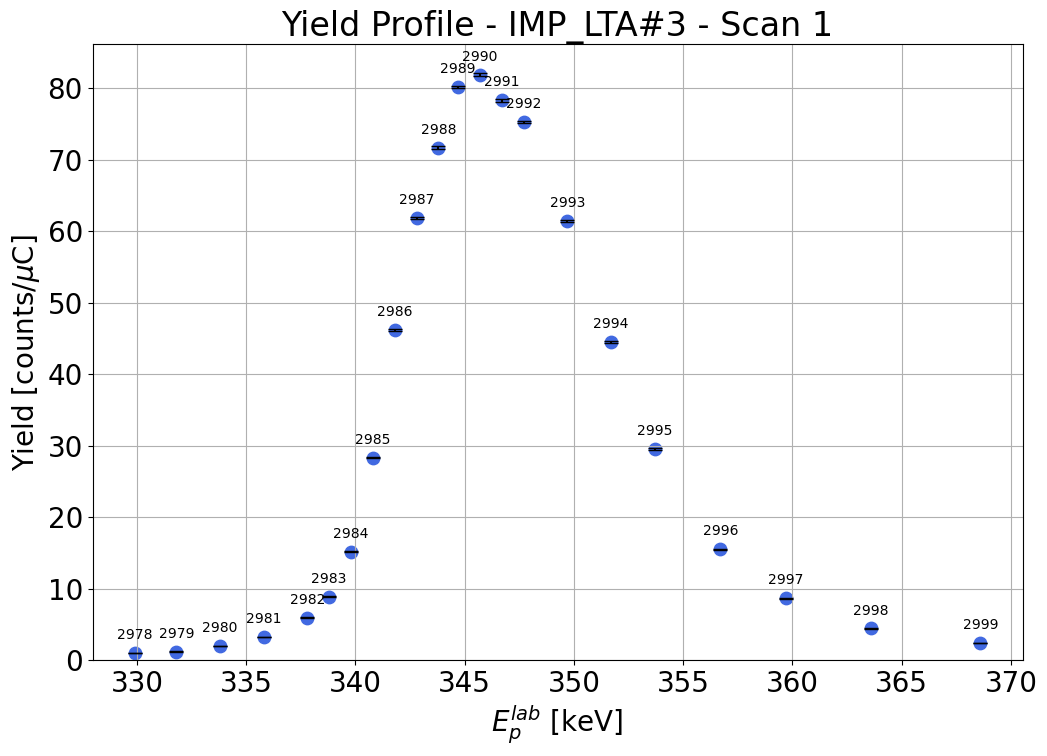

In [82]:
#   Sanity check - Plot each scan separately   #

scan_focus = 'Scan 1'
df_scan = df_results[df_results['Scan'] == scan_focus]
E_arr = df_scan['Energy'].values
Y_arr = df_scan['Yield'].values
Y_err_arr = df_scan['Yield Error'].values

plt.figure(figsize=(12,8))
plt.title(f'Yield Profile - {target} - {scan_focus}')
plt.xlabel(r'$E_p^{lab}$ [keV]')
plt.ylabel(r'Yield [counts/$\mu$C]')
plt.scatter(E_arr, Y_arr, color='royalblue', s=80)
plt.errorbar(E_arr, Y_arr, yerr=Y_err_arr, fmt='none', color='royalblue', ecolor='black', capsize=5, markersize=8)

# plot run number next to each point
for i, run in enumerate(df_scan['Run Number'].values):
    plt.annotate(f'{run}', (E_arr[i], Y_arr[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)

plt.ylim(0, None)

plt.grid()

plt.show()

In [83]:
#==================#
#   Old deadtime   #
#==================#

# for scan in scans:
#     DT_corrections.append([])
#     for run in RUNS[scans.index(scan)]:
#         f = ROOT.TFile.Open(f"/data0/biasissi/LUNA/19F+p_g+20Ne/Data/PROCESSED/run{run}.root")
#         f.cd("RawOnlyPulserSpectra")
#         dir = ROOT.gDirectory

#         # Sanity check using BGO1 TH1D and PulserOnly TH1D
#         h_BGO1 = dir.Get("BGO1")
#         if not h_BGO1 or int(h_BGO1.GetEntries()) == 0:
#             print(f"Run {run}: BGO1 missing or empty -> returning zeros")
#             f.Close()
#             print(list(np.zeros(6, float)))
#             continue

#         h_pulser = dir.Get("PulserOnly")
#         if not h_pulser or int(h_pulser.GetEntries()) == 0:
#             print(f"Run {run}: PulserOnly missing or empty -> returning zeros")
#             f.Close()
#             print(list(np.zeros(6, float)))
#             continue

#         # Get PulserOnly histogram and sum bins from 50 bin
#         nbins_pulser = h_pulser.GetNbinsX()
#         pulser_events = 0.0
#         start_bin = 50
#         if start_bin <= nbins_pulser:
#             for b in range(start_bin, nbins_pulser + 1):
#                 pulser_events += h_pulser.GetBinContent(b)

#         if pulser_events == 0.0:
#             print(f"Run {run}: no pulser events found (after bin {start_bin}) -> returning zeros")
#             f.Close()
#             print(list(np.zeros(6, float)))
#             continue

#         DT_correction = np.zeros(6, float)
#         for BGO in range(1, 7):
#             h_bgo = dir.Get(f"BGO{BGO}")
#             pulser_BGO = 0.0
#             if h_bgo:
#                 nb = h_bgo.GetNbinsX()
#                 for bb in range(1, nb + 1):
#                     pulser_BGO += h_bgo.GetBinContent(bb)

#             DT_correction[BGO - 1] = abs(1.0 - (pulser_BGO / pulser_events))

#         f.Close()

#         average_DT = np.mean(DT_correction)

#         DT_corrections[scans.index(scan)].append(average_DT)

# print(DT_corrections)